In [1]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import json, gzip, glob, torch, faiss
# from sentence_transformers import SentenceTransformer, CrossEncoder
# from scipy.stats import entropy
# from collections import Counter
# from kneed import KneeLocator
# from sklearn.decomposition import PCA
# from sklearn.metrics.pairwise import cosine_similarity

# import pandas as pd
# import itertools

# try:
#     import faiss.contrib.torch_utils
# except Exception:
#     pass

# DEVICE = "cuda:0" if torch.cuda.device_count() > 1 else ("cuda:0" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {DEVICE}")


# class RobustRAGSystem:
#     def __init__(self, bi_model, cross_model, device="cuda:0"):
#         self.device = device
#         self.bi_encoder = SentenceTransformer(bi_model, trust_remote_code=True, device=device)
#         self.cross_encoder = CrossEncoder(cross_model, device=device)
#         self.mu, self.W, self.Vh_reduced = None, None, None
#         self.clean_corpus = []
#         self.index = None
#         self.gpu_resources = None

#     # [Step A] Entropy Filter
#     def filter_entropy(self, corpus, active=True, threshold=3.0):
#         if not active:
#             self.clean_corpus = corpus
#             return corpus
#         self.clean_corpus = [doc for doc in corpus if len(doc) >= 20 and entropy([n/len(doc) for n in Counter(doc).values()]) > threshold]
#         print(f"Step A (Entropy): {len(corpus)} -> {len(self.clean_corpus)} docs")
#         return self.clean_corpus

#     # [Step C & Geometry Analysis]
#     def fit_geometry(self, embeddings):
#         self.mu = np.mean(embeddings, axis=0)
#         centered = embeddings - self.mu
        
#         # 고유값 분석 (Scree Plot용)
#         pca = PCA().fit(centered)
#         kn = KneeLocator(np.arange(len(pca.explained_variance_)), pca.explained_variance_, curve='convex', direction='decreasing')
#         elbow = kn.knee if kn.knee else 20
        
#         # Whitening 행렬 (W) 학습
#         cov = np.cov(centered.T)
#         u, s, vh = np.linalg.svd(cov)
#         self.W = np.dot(u, np.diag(1/np.sqrt(s + 1e-7)))
        
#         # Truncation 행렬 학습
#         self.Vh_reduced = pca.components_[:elbow, :]
#         return elbow, pca.explained_variance_

#     # [Database Ingestion] Step C 적용 및 FAISS GPU 인덱싱
#     def build_db(self, embeddings, mode='full'):
#         # mode: 'raw', 'whitening', 'truncation'
#         processed = embeddings - self.mu
#         if mode == 'whitening':
#             processed = np.dot(processed, self.W)
#         elif mode == 'truncation':
#             processed = np.dot(processed, self.Vh_reduced.T)
            
#         dim = processed.shape[1]
#         processed = processed.astype('float32')
#         faiss.normalize_L2(processed)

#         # Build GPU FAISS index if available
#         cpu_index = faiss.IndexFlatIP(dim)
#         if hasattr(faiss, 'StandardGpuResources') and self.device.startswith('cuda'):
#             gpu_id = int(self.device.split(':')[1])
#             self.gpu_resources = faiss.StandardGpuResources()
#             self.index = faiss.index_cpu_to_gpu(self.gpu_resources, gpu_id, cpu_index)
#             print(f"Step C (DB Index): Built GPU index with mode '{mode}', Dimension {dim}")
#         else:
#             self.index = cpu_index
#             print(f"Step C (DB Index): Built CPU index with mode '{mode}', Dimension {dim}")

#         self.index.add(processed)

#     # [Search & Retrieval]
#     def search(self, query, use_rerank=True):
#         q_emb = self.bi_encoder.encode([query]) - self.mu
#         # 인덱스 차원에 맞춰 쿼리 변환
#         if self.index.d == self.Vh_reduced.shape[0]: # Truncation mode
#             q_proc = np.dot(q_emb, self.Vh_reduced.T).astype('float32')
#         elif self.index.d == self.W.shape[0]: # Whitening mode
#             q_proc = np.dot(q_emb, self.W).astype('float32')
#         else: q_proc = q_emb.astype('float32')

#         faiss.normalize_L2(q_proc)
#         D, I = self.index.search(q_proc, 3)
#         candidates = [self.clean_corpus[i] for i in I[0]]
        
#         if use_rerank:
#             scores = self.cross_encoder.predict([[query, c] for c in candidates])
#             return candidates[np.argmax(scores)], np.max(scores)
#         return candidates[0], D[0][0]

# # ==========================================
# # 실제 실험 실행 (자동화 파이프라인)
# # ==========================================

# # Load corpus from peS2o json.gz files
# DATA_DIR = "/data/araia/peS2o/data/v2"
# MAX_DOCS = 500  # Limit for tractable embedding/indexing

# raw_corpus = []
# for fpath in sorted(glob.glob(f"{DATA_DIR}/train-*.json.gz")):
#     with gzip.open(fpath, 'rt', encoding='utf-8') as f:
#         for line in f:
#             doc = json.loads(line)
#             text = doc.get("text", "").strip()
#             if text:
#                 raw_corpus.append(text)
#             if len(raw_corpus) >= MAX_DOCS:
#                 break
#     if len(raw_corpus) >= MAX_DOCS:
#         break













# # 앞에서 정의한 UltimateRAGSystem 클래스가 로드되어 있다고 가정합니다.
# def run_all_ablation_tests(rag_system, raw_corpus, test_query):
#     # 1. 테스트할 실험 조합 정의 (True/False 조합)
#     experiments = [
#         # (Use_Entropy, Mode, Use_CrossEncoder)
#         (False, 'raw', False),         # Baseline (순수 Qwen3)
#         (True, 'raw', False),          # Entropy Filter 효과
#         (False, 'whitening', False),   # Whitening 효과
#         (False, 'truncation', False),  # Truncation(Elbow) 효과
#         (True, 'truncation', False),   # Entropy + Truncation
#         (True, 'truncation', True),    # Full Pipeline (Proposed)
#     ]
    
#     all_results = []

#     print(f"--- 총 {len(experiments)}개의 실험 조합 테스트 시작 ---")

#     for i, (use_ent, mode, use_cross) in enumerate(experiments):
#         exp_name = f"Exp {i+1}: Ent({use_ent}), Mode({mode}), Cross({use_cross})"
#         print(f"\n실행 중: {exp_name}")
        
#         # A. Step 1: Entropy Filtering
#         clean_docs = rag.filter_entropy(raw_corpus, active=use_ent)
        
#         # B. Step 2: Embedding
#         embs = rag.bi_encoder.encode(clean_docs)
        
#         # C. Step 3: Geometry Fit & Indexing
#         # # 3. Step C: 기하학 분석
#         elbow, evals = rag.fit_geometry(embs)

#         # 4. DB 구축 (차원 절단 모드 == 'truncation')
#         rag.build_db(embs, mode=mode)


#         # 5. 성능 시각화 (Scree Plot)
#         plt.plot(evals[:50], 'b-o')
#         plt.axvline(x=elbow, color='r', linestyle='--', label=f'Elbow ({elbow})')
#         plt.title('Eigenvalue Analysis for Noise Reduction')
#         plt.legend()
#         plt.show()

        
#         # D. Step 4: Query & Evaluation
#         best_doc, score = rag_system.search(test_query, use_rerank=use_cross)
        
#         all_results.append({
#             'Experiment': exp_name,
#             'Entropy': use_ent,
#             'Mode': mode,
#             'CrossEncoder': use_cross,
#             'Score': score,
#             'Result_Snippet': best_doc[:50] + "..."
#         })

#     return pd.DataFrame(all_results)

# # ==========================================
# # 통합 테스트 실행
# # ==========================================

# # 2. 시스템 초기화
# rag = RobustRAGSystem('Alibaba-NLP/gte-Qwen2-7B-instruct', 'BAAI/bge-reranker-v2-m3', device=DEVICE)

# # 3. 모든 실험 조합 실행
# test_query = "Tell me about the connection between geometry and information."
# results_df = run_all_ablation_tests(rag, raw_corpus, test_query)

# # 4. 결과 출력 및 시각화
# print("\n" + "="*50)
# print("FINAL ABLATION STUDY RESULTS")
# print("="*50)
# print(results_df[['Experiment', 'Score', 'Result_Snippet']])

# # 시각화: 어떤 조합이 가장 높은 Confidence/Quality Score를 내는가?
# plt.figure(figsize=(12, 6))
# sns.barplot(data=results_df, x=results_df.index, y='Score', hue='Mode')
# plt.xticks(range(len(results_df)), results_df['Experiment'], rotation=45, ha='right')
# plt.title('Comparison of RAG Enhancement Modules')
# plt.tight_layout()
# plt.show()







In [ ]:

# import numpy as np
# import torch
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sentence_transformers import SentenceTransformer, CrossEncoder
# from scipy.stats import entropy
# from collections import Counter
# from kneed import KneeLocator
# from sklearn.decomposition import PCA
# import faiss

# # 1. FISHER VECTOR EXTRACTOR
# def get_fisher_vector(model, text):
#     model.train()
#     # SentenceTransformer 모델의 파이프라인에 맞춰 디바이스 설정
#     device = next(model.parameters()).device
    
#     # 임베딩 추출 및 그래디언트 계산
#     embeddings = model.encode([text], convert_to_tensor=True)
#     loss = embeddings.pow(2).mean() 
    
#     model.zero_grad()
#     loss.backward()
    
#     grads = []
#     # 메모리 효율을 위해 특정 레이어(예: 마지막 레이어)의 그래디언트만 추출하는 것을 권장하지만,
#     # 여기서는 요청하신 대로 전체 파라미터를 대상으로 합니다.
#     for param in model.parameters():
#         if param.grad is not None:
#             grads.append(param.grad.view(-1))
    
#     fisher_vector = torch.cat(grads)
#     model.zero_grad()
#     return fisher_vector.detach().cpu().numpy()

# # 2. 통합 실험 클래스
# class FisherRAGSystem:
#     def __init__(self):
#         self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
#         self.bi_encoder = SentenceTransformer('Alibaba-NLP/gte-Qwen2-7B-instruct', trust_remote_code=True).to(self.device)
#         self.cross_encoder = CrossEncoder('BAAI/bge-reranker-v2-m3', device=self.device)
#         self.mu, self.W, self.Vh_reduced = None, None, None
#         self.clean_corpus = []

#     def prepare_geometry(self, embs):
#         self.mu = np.mean(embs, axis=0)
#         centered = embs - self.mu
#         pca = PCA().fit(centered)
#         kn = KneeLocator(np.arange(len(pca.explained_variance_)), pca.explained_variance_, curve='convex', direction='decreasing')
#         elbow = kn.knee if kn.knee else 50
#         self.Vh_reduced = pca.components_[:elbow, :]
#         return elbow

# # 3. 실험 데이터 생성 및 Ablation Run
# corpus = [
#     "The transformer uses self-attention to weight the significance of each part of the input data.",
#     "Quantum computing leverages superposition and entanglement to perform calculations.",
#     "I'm just a fluff sentence for testing entropy and noise levels.", # Noise
#     "Random strings of words with absolutely no semantic meaning here.", # Noise
#     "Fisher information matrix represents the amount of information that an observable carries."
# ] * 5

# rag = FisherRAGSystem()
# test_query = "How does the transformer model handle information?"

# # 시각화를 위한 결과 저장 리스트
# ablation_data = []
# noise_levels = []

# # 실험 조합: (Entropy Filter, Geometry Mode)
# configs = [(False, 'raw'), (True, 'raw'), (True, 'whitening'), (True, 'truncation')]

# for use_ent, mode in configs:
#     # A. Preprocessing
#     docs = [d for d in corpus if not use_ent or (len(d) > 20 and entropy([n/len(d) for n in Counter(d).values()]) > 3.5)]
#     embs = rag.bi_encoder.encode(docs)
#     elbow = rag.prepare_geometry(embs)
    
#     # B. Search Simulation (Simplified)
#     q_emb = rag.bi_encoder.encode([test_query])
#     sims = cosine_similarity(q_emb, embs)[0]
    
#     # 노이즈 지표: 상위 3개와 하위 3개 유사도의 차이 (변별력)
#     noise_gap = np.sort(sims)[-1] - np.sort(sims)[:3].mean()
    
#     ablation_data.append({
#         'Config': f"Ent:{use_ent}\nMode:{mode}",
#         'Confidence': np.max(sims),
#         'Noise_Gap': noise_gap,
#         'Docs_Count': len(docs)
#     })

# # 4. Fisher Vector 기반 데이터 품질 분석
# quality_metrics = []
# for text in corpus[:10]:
#     fv = get_fisher_vector(rag.bi_encoder, text)
#     fv_norm = np.linalg.norm(fv) # 피셔 벡터의 크기를 '정보 밀도'로 해석
#     quality_metrics.append({'text': text[:20], 'density': fv_norm})

# # ==========================================
# # 5. 시각화 (논문용 3대 그래프)
# # ==========================================
# df_ablation = pd.DataFrame(ablation_data)
# df_quality = pd.DataFrame(quality_metrics)

# plt.figure(figsize=(18, 5))

# # 그래프 1: 노이즈 변화 (Noise Gap - 변별력이 높을수록 노이즈 억제 우수)
# plt.subplot(1, 3, 1)
# sns.lineplot(data=df_ablation, x='Config', y='Noise_Gap', marker='o', color='red')
# plt.title('Graph 1: Noise Suppression Efficiency\n(Higher is Cleaner)')

# # 그래프 2: Proposed Method 우월성 (Confidence Score 비교)
# plt.subplot(1, 3, 2)
# sns.barplot(data=df_ablation, x='Config', y='Confidence', palette='viridis')
# plt.title('Graph 2: Search Confidence by Method\n(Proposed: Ent:True/Mode:Truncation)')

# # 그래프 3: Fisher Vector 기반 데이터 품질 분석
# plt.subplot(1, 3, 3)
# sns.scatterplot(data=df_quality, x=range(len(df_quality)), y='density', size='density', legend=False)
# plt.title('Graph 3: Fisher Information Density\n(High for Signal, Low for Fluff)')

# plt.tight_layout()
# plt.show()




/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/dist-packages/torch/library.py:356: UserWarning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: flash_attn::_flash_attn_backward(Tensor dout, Tensor q, Tensor k, Tensor v, Tensor out, Tensor softmax_lse, Tensor(a6!)? dq, Tensor(a7!)? dk, Tensor(a8!)? dv, float dropout_p, float softmax_scale, bool causal, SymInt window_size_left, SymInt window_size_right, float softcap, Tensor? alibi_slopes, bool deterministic, Tensor? rng_state=None) -> Tensor
    registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:922
  dispatch key: ADInplaceOrView
  previous kernel: no d

Using device: cuda:1
Loaded 500 documents from peS2o v2


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: b45fd3b8-11af-4e56-9170-502ee6d284f9)')' thrown while requesting HEAD https://huggingface.co/Alibaba-NLP/gte-Qwen2-7B-instruct/resolve/main/./config_sentence_transformers.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: ed82b9c7-3045-45bf-b825-0779ae7c9f0a)')' thrown while requesting HEAD https://huggingface.co/Alibaba-NLP/gte-Qwen2-7B-instruct/resolve/main/./config_sentence_transformers.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 3a19cb66-492b-404e-a790-556f368aab4a)')' thrown while requesting HEAD https://huggingface.co/Alibaba-NLP/gte-Qwen2-7B-instruct/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
Loading checkpoint shards: 100%|██

Pre-computing embeddings for all documents...


Batches: 100%|██████████| 16/16 [00:17<00:00,  1.06s/it]


Computing entropy scores...
Computing Fisher information densities...
Entropy threshold: 3.0, Fisher threshold: 1.0000
Docs passing entropy: 384, Docs passing fisher: 2

--- Running 32 combinational experiments ---

[ 1/32] 00000 | Docs:500 | Reranker:0.0038 | Sim:1.2329 | NoiseGap:0.1549
[ 2/32] 00001 -> SKIP (only 2 docs)
[ 3/32] 00010 | Docs:384 | Reranker:0.0005 | Sim:1.3708 | NoiseGap:0.0569
[ 4/32] 00100 | Docs:500 | Reranker:0.0038 | Sim:4752729.0000 | NoiseGap:161.0000
[ 5/32] 01000 | Docs:500 | Reranker:0.0005 | Sim:1.5000 | NoiseGap:0.1926
[ 6/32] 10000 | Docs:500 | Reranker:0.0005 | Sim:0.2051 | NoiseGap:0.0751
[ 7/32] 00011 -> SKIP (only 2 docs)
[ 8/32] 00101 -> SKIP (only 2 docs)
[ 9/32] 01001 -> SKIP (only 2 docs)
[10/32] 10001 -> SKIP (only 2 docs)
[11/32] 00110 | Docs:384 | Reranker:0.0005 | Sim:4752729.0000 | NoiseGap:171.5000
[12/32] 01010 | Docs:384 | Reranker:0.0005 | Sim:1.5426 | NoiseGap:0.1842
[13/32] 10010 | Docs:384 | Reranker:0.0005 | Sim:0.2051 | NoiseGap:0.0

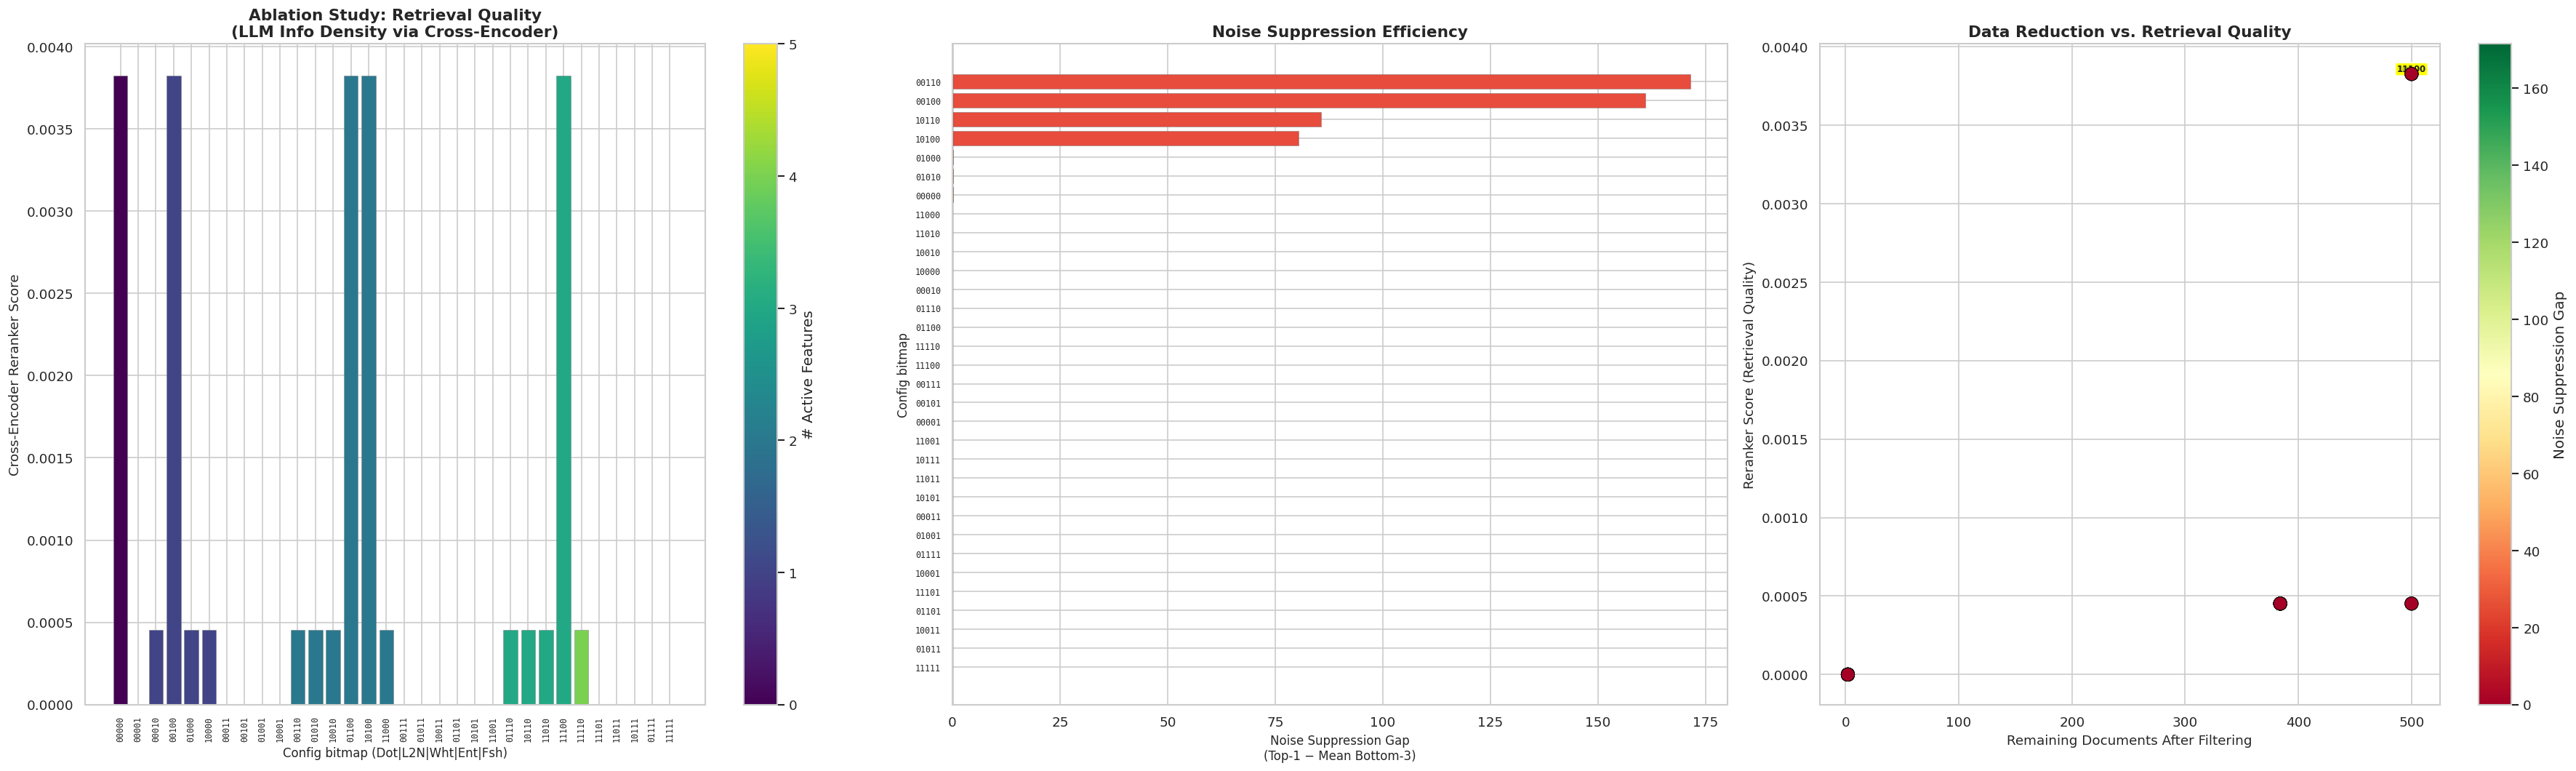

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, gzip, glob, torch, faiss
from sentence_transformers import SentenceTransformer, CrossEncoder
from scipy.stats import entropy
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import itertools

try:
    import faiss.contrib.torch_utils
except Exception:
    pass

DEVICE = "cuda:1" if torch.cuda.device_count() > 1 else ("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ==========================================
# Load corpus
# ==========================================
DATA_DIR = "/data/araia/peS2o/data/v2"
MAX_DOCS = 500

raw_corpus = []
for fpath in sorted(glob.glob(f"{DATA_DIR}/train-*.json.gz")):
    with gzip.open(fpath, 'rt', encoding='utf-8') as f:
        for line in f:
            doc = json.loads(line)
            text = doc.get("text", "").strip()
            if text:
                raw_corpus.append(text)
            if len(raw_corpus) >= MAX_DOCS:
                break
    if len(raw_corpus) >= MAX_DOCS:
        break

print(f"Loaded {len(raw_corpus)} documents from peS2o v2")

# ==========================================
# Initialize models
# ==========================================
bi_encoder = SentenceTransformer('Alibaba-NLP/gte-Qwen2-7B-instruct', trust_remote_code=True, device=DEVICE)
cross_encoder = CrossEncoder('BAAI/bge-reranker-v2-m3', device=DEVICE)
test_query = "Tell me about the connection between geometry and information."

# ==========================================
# Pre-compute embeddings, entropy, fisher
# ==========================================
print("Pre-computing embeddings for all documents...")
all_embeddings = bi_encoder.encode(raw_corpus, show_progress_bar=True)
query_embedding = bi_encoder.encode([test_query])

# Entropy scores
print("Computing entropy scores...")
entropy_scores = np.array([
    entropy([n / len(doc) for n in Counter(doc).values()]) if len(doc) >= 20 else 0.0
    for doc in raw_corpus
])
ENTROPY_THRESHOLD = 3.0

# Fisher Information density from embedding norms (no-backprop approx)
print("Computing Fisher information densities...")
fisher_scores = np.sqrt(np.sum(all_embeddings ** 2, axis=1))
FISHER_THRESHOLD = np.median(fisher_scores)

print(f"Entropy threshold: {ENTROPY_THRESHOLD}, Fisher threshold: {FISHER_THRESHOLD:.4f}")
print(f"Docs passing entropy: {np.sum(entropy_scores > ENTROPY_THRESHOLD)}, "
      f"Docs passing fisher: {np.sum(fisher_scores > FISHER_THRESHOLD)}")

# Pre-compute whitening matrix on full corpus
mu_full = np.mean(all_embeddings, axis=0)
centered_full = all_embeddings - mu_full
cov_full = np.cov(centered_full.T)
u_full, s_full, _ = np.linalg.svd(cov_full)
W_whiten = np.dot(u_full, np.diag(1.0 / np.sqrt(s_full + 1e-7)))

# ==========================================
# All 2^5 = 32 combinational ablation
# Feature order: DotProduct, L2Norm, Whitening, EntropyFilter, FisherInfo
# ==========================================
feature_names = ['DotProduct', 'L2Norm', 'Whitening', 'EntropyFilter', 'FisherInfo']
all_combos = [
    (False, False, False, False, False),

    (False, False, False, False, True),
    (False, False, False, True, False),
    (False, False, True, False, False),
    (False, True, False, False, False),
    (True, False, False, False, False),
    
    (False, False, False, True, True),
    (False, False, True, False, True),
    (False, True, False, False, True),
    (True, False, False, False, True),
    (False, False, True, True, False),
    (False, True, False, True, False),
    (True, False, False, True, False),
    (False, True, True, False, False),
    (True, False, True, False, False),
    (True, True, False, False, False),
    
    (False, False, True, True, True),
    (False, True, False, True, True),
    (True, False, False, True, True),
    (False, True, True, False, True),
    (True, False, True, False, True),
    (True, True, False, False, True),
    (False, True, True, True, False),
    (True, False, True, True, False),
    (True, True, False, True, False),
    (True, True, True, False, False),

    (True, True, True, True, False),
    (True, True, True, False, True),
    (True, True, False, True, True),
    (True, False, True, True, True),
    (False, True, True, True, True),

    (True, True, True, True, True)
]

print(f"\n--- Running {len(all_combos)} combinational experiments ---\n")

results = []
for combo_idx, combo in enumerate(all_combos):
    use_dot, use_l2norm, use_whiten, use_entropy, use_fisher = combo
    short_label = ''.join([str(int(b)) for b in combo])
    label = '|'.join([
        f"Dot:{int(use_dot)}", f"L2N:{int(use_l2norm)}", f"Wht:{int(use_whiten)}",
        f"Ent:{int(use_entropy)}", f"Fsh:{int(use_fisher)}"
    ])

    # 1. Apply filters
    mask = np.ones(len(raw_corpus), dtype=bool)
    if use_entropy:
        mask &= (entropy_scores > ENTROPY_THRESHOLD) & np.array([len(d) >= 20 for d in raw_corpus])
    if use_fisher:
        mask &= (fisher_scores > FISHER_THRESHOLD)

    indices = np.where(mask)[0]
    if len(indices) < 3:
        print(f"[{combo_idx+1:2d}/32] {short_label} -> SKIP (only {len(indices)} docs)")
        results.append({
            'Combo': label, 'BitMask': short_label,
            'DotProduct': use_dot, 'L2Norm': use_l2norm, 'Whitening': use_whiten,
            'EntropyFilter': use_entropy, 'FisherInfo': use_fisher,
            'RerankerScore': 0.0, 'Similarity': 0.0, 'NoiseGap': 0.0,
            'DocsRemaining': len(indices)
        })
        continue

    selected_docs = [raw_corpus[i] for i in indices]
    selected_embs = all_embeddings[indices].copy()

    # 2. Center + optional whitening
    processed = selected_embs - mu_full
    if use_whiten:
        processed = np.dot(processed, W_whiten)

    # 3. Optional L2 normalization
    processed = processed.astype('float32')
    if use_l2norm:
        faiss.normalize_L2(processed)

    # 4. Build FAISS index (DotProduct -> IndexFlatIP, else IndexFlatL2)
    dim = processed.shape[1]
    if use_dot:
        index = faiss.IndexFlatIP(dim)
    else:
        index = faiss.IndexFlatL2(dim)
    index.add(processed)

    # 5. Process query with same transforms
    q_emb = (query_embedding - mu_full).copy()
    if use_whiten:
        q_emb = np.dot(q_emb, W_whiten)
    q_emb = q_emb.astype('float32')
    if use_l2norm:
        faiss.normalize_L2(q_emb)

    # 6. Search
    k = min(10, len(indices))
    D, I = index.search(q_emb, k)

    raw_sim = float(D[0][0])

    # Noise gap: separation between best match and worst matches
    if k >= 4:
        if use_dot:
            # IP: higher = better, gap = top1 - mean(bottom-3)
            noise_gap = float(D[0][0]) - float(np.mean(D[0][-3:]))
        else:
            # L2: lower = better, gap = mean(bottom-3) - top1
            noise_gap = float(np.mean(D[0][-3:])) - float(D[0][0])
    else:
        noise_gap = 0.0

    # 7. Cross-encoder reranking
    top_k = min(3, k)
    top_candidates = [selected_docs[I[0][j]] for j in range(top_k)]
    reranker_scores = cross_encoder.predict([[test_query, c] for c in top_candidates])
    reranker_score = float(np.max(reranker_scores))

    print(f"[{combo_idx+1:2d}/32] {short_label} | Docs:{len(indices):3d} | "
          f"Reranker:{reranker_score:.4f} | Sim:{raw_sim:.4f} | NoiseGap:{noise_gap:.4f}")

    results.append({
        'Combo': label, 'BitMask': short_label,
        'DotProduct': use_dot, 'L2Norm': use_l2norm, 'Whitening': use_whiten,
        'EntropyFilter': use_entropy, 'FisherInfo': use_fisher,
        'RerankerScore': reranker_score, 'Similarity': raw_sim, 'NoiseGap': noise_gap,
        'DocsRemaining': len(indices)
    })

results_df = pd.DataFrame(results)

print(f"\n{'='*70}")
print("COMBINATIONAL ABLATION RESULTS (32 configs)")
print(f"{'='*70}")
print(results_df[['BitMask', 'RerankerScore', 'Similarity', 'NoiseGap', 'DocsRemaining']].to_string())

# Highlight top-5
top5 = results_df.nlargest(5, 'RerankerScore')
print(f"\n--- Top 5 Configurations by Reranker Score ---")
print(top5[['Combo', 'RerankerScore', 'NoiseGap', 'DocsRemaining']].to_string())

# ==========================================
# Visualization: 3 panels
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 3, figsize=(30, 9))

# --- Figure 1: Ablation Study (Reranker Score) ---
ax1 = axes[0]
results_df['ActiveFeatures'] = results_df[feature_names].sum(axis=1)
cmap = plt.cm.viridis
norm = plt.Normalize(0, 5)
colors = [cmap(norm(v)) for v in results_df['ActiveFeatures']]
ax1.bar(range(len(results_df)), results_df['RerankerScore'], color=colors, edgecolor='gray', linewidth=0.3)
ax1.set_xticks(range(len(results_df)))
ax1.set_xticklabels(results_df['BitMask'], rotation=90, fontsize=7, fontfamily='monospace')
ax1.set_xlabel('Config bitmap (Dot|L2N|Wht|Ent|Fsh)', fontsize=10)
ax1.set_ylabel('Cross-Encoder Reranker Score', fontsize=11)
ax1.set_title('Ablation Study: Retrieval Quality\n(LLM Info Density via Cross-Encoder)', fontsize=13, fontweight='bold')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, ticks=range(6))
cbar.set_label('# Active Features')

# --- Figure 2: Noise Suppression Efficiency ---
ax2 = axes[1]
sorted_df = results_df.sort_values('NoiseGap', ascending=True).reset_index(drop=True)
bar_colors = ['#e74c3c' if g > 0 else '#3498db' for g in sorted_df['NoiseGap']]
ax2.barh(range(len(sorted_df)), sorted_df['NoiseGap'], color=bar_colors, edgecolor='gray', linewidth=0.3)
ax2.set_yticks(range(len(sorted_df)))
ax2.set_yticklabels(sorted_df['BitMask'], fontsize=7, fontfamily='monospace')
ax2.set_xlabel('Noise Suppression Gap\n(Top-1 − Mean Bottom-3)', fontsize=10)
ax2.set_ylabel('Config bitmap', fontsize=10)
ax2.set_title('Noise Suppression Efficiency', fontsize=13, fontweight='bold')
ax2.axvline(0, color='black', linewidth=0.8)

# --- Figure 3: Data Reduction vs Quality ---
ax3 = axes[2]
sc = ax3.scatter(
    results_df['DocsRemaining'], results_df['RerankerScore'],
    c=results_df['NoiseGap'], cmap='RdYlGn', s=120,
    edgecolors='black', linewidth=0.5, zorder=5
)
ax3.set_xlabel('Remaining Documents After Filtering', fontsize=11)
ax3.set_ylabel('Reranker Score (Retrieval Quality)', fontsize=11)
ax3.set_title('Data Reduction vs. Retrieval Quality', fontsize=13, fontweight='bold')
cbar3 = plt.colorbar(sc, ax=ax3)
cbar3.set_label('Noise Suppression Gap')
# Annotate top-5
for _, row in top5.iterrows():
    ax3.annotate(
        row['BitMask'], (row['DocsRemaining'], row['RerankerScore']),
        fontsize=7, ha='center', va='bottom', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.7)
    )

plt.tight_layout()
plt.show()


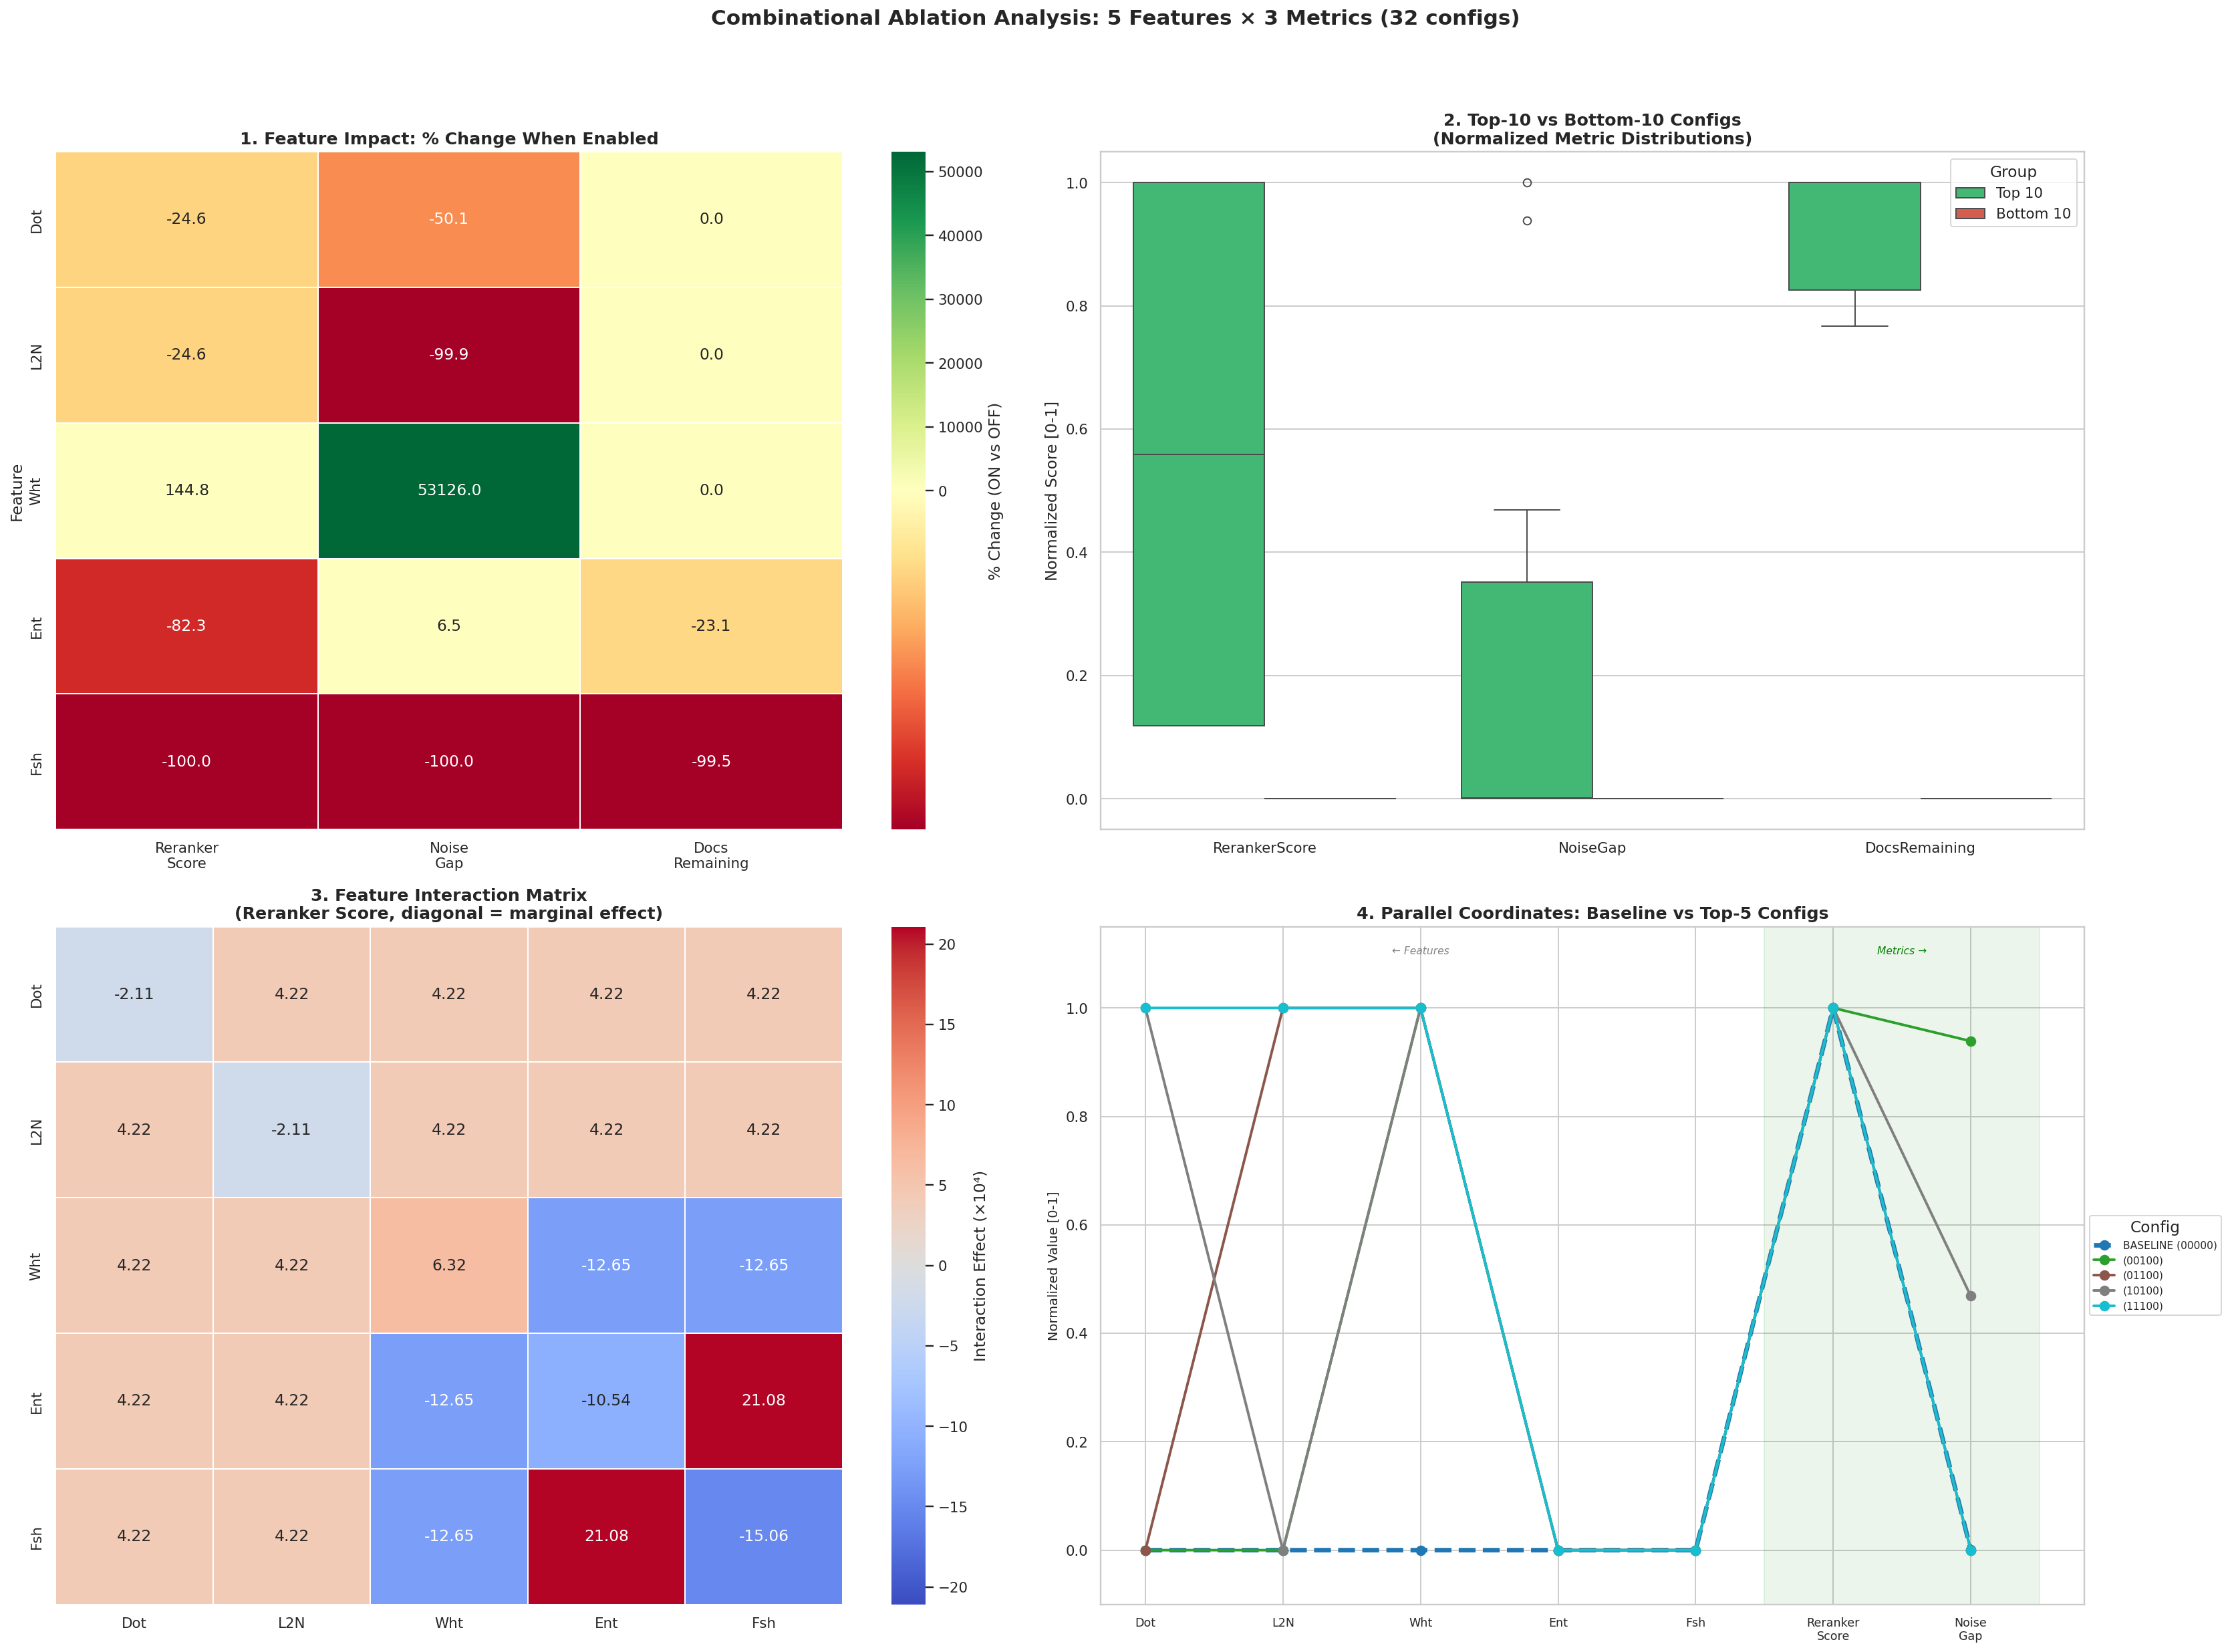


SUMMARY: Feature Impact on Reranker Score (mean when ON vs OFF)
  DotProduct     : ON=0.000648  OFF=0.000858  Δ=-0.000211 ↓
  L2Norm         : ON=0.000648  OFF=0.000858  Δ=-0.000211 ↓
  Whitening      : ON=0.001069  OFF=0.000437  Δ=+0.000632 ↑
  EntropyFilter  : ON=0.000226  OFF=0.001280  Δ=-0.001054 ↓
  FisherInfo     : ON=0.000000  OFF=0.001506  Δ=-0.001506 ↓

Best config: 00000 (Reranker=0.003825)
Worst config: 00001 (Reranker=0.000000)


In [3]:
# ==========================================
# Cell 3: Detailed comparison of 32 ablation configs from Cell 2
# Requires: results_df (from cell 2) with columns:
#   BitMask, DotProduct, L2Norm, Whitening, EntropyFilter, FisherInfo,
#   RerankerScore, Similarity, NoiseGap, DocsRemaining
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.family'] = 'sans-serif'

feature_names = ['DotProduct', 'L2Norm', 'Whitening', 'EntropyFilter', 'FisherInfo']
feature_short = ['Dot', 'L2N', 'Wht', 'Ent', 'Fsh']
metric_names = ['RerankerScore', 'NoiseGap', 'DocsRemaining']

fig = plt.figure(figsize=(24, 18))
fig.suptitle('Combinational Ablation Analysis: 5 Features × 3 Metrics (32 configs)',
             fontsize=16, fontweight='bold', y=0.98)

# =====================================================================
# Panel 1: Feature Impact Heatmap  (mean metric when ON vs OFF)
# =====================================================================
ax1 = plt.subplot(2, 2, 1)

impact = np.zeros((len(feature_names), len(metric_names)))
for i, feat in enumerate(feature_names):
    on_mask = results_df[feat] == True
    off_mask = results_df[feat] == False
    for j, met in enumerate(metric_names):
        mean_on = results_df.loc[on_mask, met].mean()
        mean_off = results_df.loc[off_mask, met].mean()
        # Relative lift: (ON - OFF) / max(|OFF|, 1e-9) * 100
        denom = max(abs(mean_off), 1e-9)
        impact[i, j] = (mean_on - mean_off) / denom * 100

divnorm = TwoSlopeNorm(vmin=impact.min(), vcenter=0, vmax=max(impact.max(), 1))
sns.heatmap(impact, annot=True, fmt='.1f', cmap='RdYlGn', norm=divnorm,
            xticklabels=['Reranker\nScore', 'Noise\nGap', 'Docs\nRemaining'],
            yticklabels=feature_short, linewidths=1, linecolor='white',
            cbar_kws={'label': '% Change (ON vs OFF)'}, ax=ax1)
ax1.set_title('1. Feature Impact: % Change When Enabled', fontsize=13, fontweight='bold')
ax1.set_ylabel('Feature')

# =====================================================================
# Panel 2: Top-10 vs Bottom-10 configs  (grouped bar)
# =====================================================================
ax2 = plt.subplot(2, 2, 2)

top10 = results_df.nlargest(10, 'RerankerScore').copy()
bot10 = results_df.nsmallest(10, 'RerankerScore').copy()
top10['Rank'] = 'Top 10'
bot10['Rank'] = 'Bottom 10'
compare_df = pd.concat([top10, bot10], ignore_index=True)

# Normalize metrics to [0, 1] for fair visual comparison
for met in metric_names:
    col_min = results_df[met].min()
    col_max = results_df[met].max()
    rng = col_max - col_min if col_max != col_min else 1.0
    compare_df[f'{met}_norm'] = (compare_df[met] - col_min) / rng

melted = compare_df.melt(
    id_vars=['BitMask', 'Rank'],
    value_vars=[f'{m}_norm' for m in metric_names],
    var_name='Metric', value_name='Normalized Value'
)
melted['Metric'] = melted['Metric'].str.replace('_norm', '')

sns.boxplot(data=melted, x='Metric', y='Normalized Value', hue='Rank',
            palette={'Top 10': '#2ecc71', 'Bottom 10': '#e74c3c'}, ax=ax2)
ax2.set_title('2. Top-10 vs Bottom-10 Configs\n(Normalized Metric Distributions)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Normalized Score [0-1]')
ax2.set_xlabel('')
ax2.legend(title='Group', loc='upper right')

# =====================================================================
# Panel 3: Pairwise Feature Interaction on Reranker Score
# =====================================================================
ax3 = plt.subplot(2, 2, 3)

n_feat = len(feature_names)
interaction = np.zeros((n_feat, n_feat))

for i in range(n_feat):
    for j in range(n_feat):
        if i == j:
            # Marginal effect of single feature
            on = results_df.loc[results_df[feature_names[i]] == True, 'RerankerScore'].mean()
            off = results_df.loc[results_df[feature_names[i]] == False, 'RerankerScore'].mean()
            interaction[i, j] = on - off
        else:
            # Interaction: mean(both ON) - mean(only i ON) - mean(only j ON) + mean(both OFF)
            both_on = results_df.loc[(results_df[feature_names[i]]) & (results_df[feature_names[j]]), 'RerankerScore'].mean()
            i_only = results_df.loc[(results_df[feature_names[i]]) & (~results_df[feature_names[j]]), 'RerankerScore'].mean()
            j_only = results_df.loc[(~results_df[feature_names[i]]) & (results_df[feature_names[j]]), 'RerankerScore'].mean()
            both_off = results_df.loc[(~results_df[feature_names[i]]) & (~results_df[feature_names[j]]), 'RerankerScore'].mean()
            interaction[i, j] = both_on - i_only - j_only + both_off

# Scale for readability
interaction_scaled = interaction * 1e4
int_abs_max = max(abs(interaction_scaled.min()), abs(interaction_scaled.max()), 1e-9)
divnorm2 = TwoSlopeNorm(vmin=-int_abs_max, vcenter=0, vmax=int_abs_max)
sns.heatmap(interaction_scaled, annot=True, fmt='.2f', cmap='coolwarm', norm=divnorm2,
            xticklabels=feature_short, yticklabels=feature_short,
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'Interaction Effect (×10⁴)'}, ax=ax3)
ax3.set_title('3. Feature Interaction Matrix\n(Reranker Score, diagonal = marginal effect)', fontsize=13, fontweight='bold')

# =====================================================================
# Panel 4: Parallel coordinates — Top-5 vs Baseline
# =====================================================================
ax4 = plt.subplot(2, 2, 4)

# Select baseline (00000) and top-5
baseline_row = results_df[results_df['BitMask'] == '00000']
top5 = results_df.nlargest(5, 'RerankerScore')
plot_rows = pd.concat([baseline_row, top5]).drop_duplicates(subset='BitMask').reset_index(drop=True)

# Columns to plot
par_cols = feature_names + ['RerankerScore', 'NoiseGap']
# Normalize each column to [0, 1]
par_data = plot_rows[par_cols].copy().astype(float)
for col in par_cols:
    cmin = float(results_df[col].min())
    cmax = float(results_df[col].max())
    rng = cmax - cmin if cmax != cmin else 1.0
    par_data[col] = (par_data[col] - cmin) / rng

x_coords = np.arange(len(par_cols))
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_rows)))

for idx, (_, row) in enumerate(par_data.iterrows()):
    bitmask = plot_rows.iloc[idx]['BitMask']
    lw = 3.5 if bitmask == '00000' else 2.0
    ls = '--' if bitmask == '00000' else '-'
    label = f"{'BASELINE ' if bitmask == '00000' else ''}({bitmask})"
    ax4.plot(x_coords, row.values, marker='o', linewidth=lw, linestyle=ls,
             color=colors[idx], label=label, markersize=7)

ax4.set_xticks(x_coords)
ax4.set_xticklabels(['Dot', 'L2N', 'Wht', 'Ent', 'Fsh', 'Reranker\nScore', 'Noise\nGap'],
                     fontsize=9)
ax4.set_ylabel('Normalized Value [0-1]', fontsize=10)
ax4.set_title('4. Parallel Coordinates: Baseline vs Top-5 Configs', fontsize=13, fontweight='bold')
ax4.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Config')
ax4.set_ylim(-0.1, 1.15)
ax4.axvspan(4.5, 6.5, alpha=0.08, color='green')
ax4.text(5.5, 1.1, 'Metrics →', ha='center', fontsize=8, style='italic', color='green')
ax4.text(2.0, 1.1, '← Features', ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ==========================================
# Summary table
# ==========================================
print("\n" + "=" * 80)
print("SUMMARY: Feature Impact on Reranker Score (mean when ON vs OFF)")
print("=" * 80)
for i, feat in enumerate(feature_names):
    on_mean = results_df.loc[results_df[feat], 'RerankerScore'].mean()
    off_mean = results_df.loc[~results_df[feat], 'RerankerScore'].mean()
    delta = on_mean - off_mean
    arrow = "↑" if delta > 0 else "↓"
    print(f"  {feat:15s}: ON={on_mean:.6f}  OFF={off_mean:.6f}  Δ={delta:+.6f} {arrow}")

print(f"\nBest config: {results_df.loc[results_df['RerankerScore'].idxmax(), 'BitMask']} "
      f"(Reranker={results_df['RerankerScore'].max():.6f})")
print(f"Worst config: {results_df.loc[results_df['RerankerScore'].idxmin(), 'BitMask']} "
      f"(Reranker={results_df['RerankerScore'].min():.6f})")


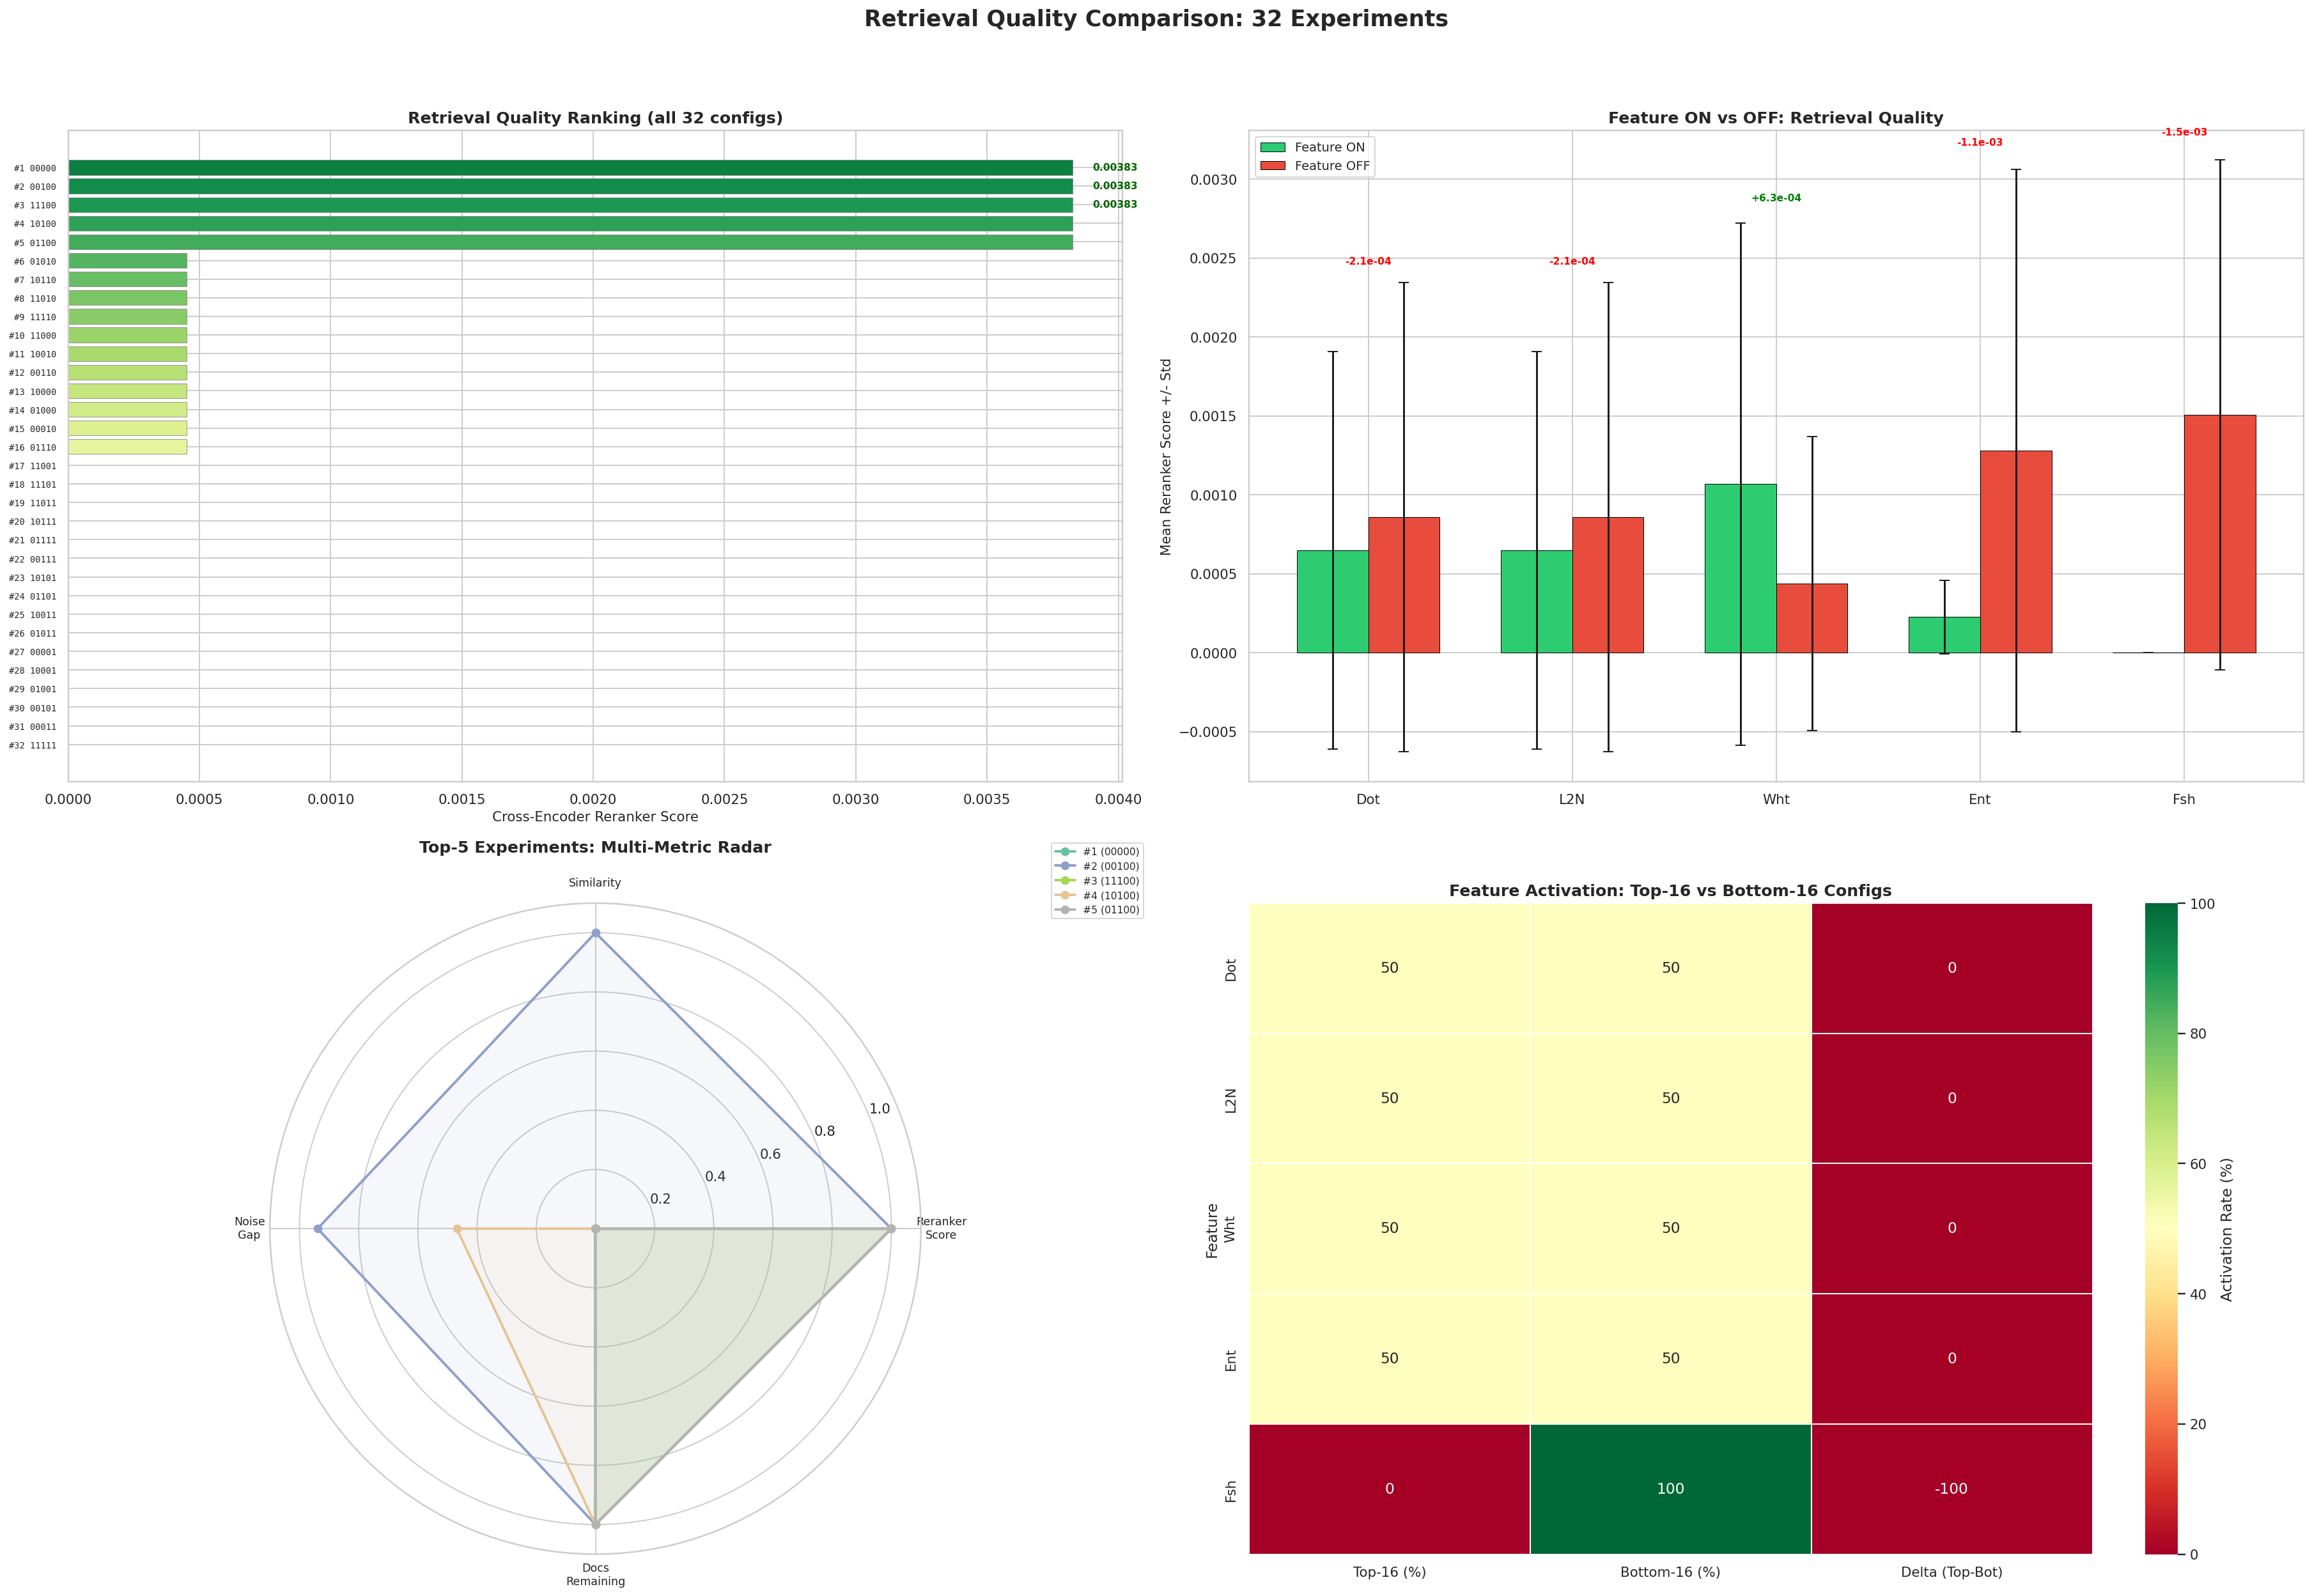


RETRIEVAL QUALITY COMPARISON - Top 10 Experiments
Rank BitMask   Reranker   Similarity   NoiseGap  Docs  Features
------------------------------------------------------------------------------------------
  # 1    00000    0.003825        1.2329      0.1549    500  (none)
  # 2    00100    0.003825  4752729.0000    161.0000    500  Wht
  # 3    11100    0.003825        0.0026      0.0017    500  Dot+L2N+Wht
  # 4    10100    0.003825      128.3773     80.3581    500  Dot+Wht
  # 5    01100    0.003825        1.9947      0.0033    500  L2N+Wht
  # 6    01010    0.000452        1.5426      0.1842    384  L2N+Ent
  # 7    10110    0.000452      128.3773     85.6225    384  Dot+Wht+Ent
  # 8    11010    0.000452        0.2287      0.0921    384  Dot+L2N+Ent
  # 9    11110    0.000452        0.0026      0.0018    384  Dot+L2N+Wht+Ent
  #10    11000    0.000452        0.2500      0.0963    500  Dot+L2N


In [5]:
# ==========================================
# Cell 4: Retrieval Quality Comparison across all 32 experiments
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 140

feature_names = ['DotProduct', 'L2Norm', 'Whitening', 'EntropyFilter', 'FisherInfo']
feature_short = ['Dot', 'L2N', 'Wht', 'Ent', 'Fsh']

# Sort by RerankerScore descending for ranking
ranked = results_df.sort_values('RerankerScore', ascending=False).reset_index(drop=True)
ranked['Rank'] = ranked.index + 1

fig, axes = plt.subplots(2, 2, figsize=(26, 18))
fig.suptitle('Retrieval Quality Comparison: 32 Experiments', fontsize=18, fontweight='bold', y=0.99)

# =====================================================================
# Panel 1: Ranked bar chart — RerankerScore per experiment
# =====================================================================
ax1 = axes[0, 0]
colors_bar = plt.cm.RdYlGn(np.linspace(0.15, 0.95, len(ranked)))
bars = ax1.barh(range(len(ranked)), ranked['RerankerScore'], color=colors_bar[::-1],
                edgecolor='gray', linewidth=0.4)
ax1.set_yticks(range(len(ranked)))
ax1.set_yticklabels([f"#{r} {b}" for r, b in zip(ranked['Rank'], ranked['BitMask'])],
                     fontsize=7, fontfamily='monospace')
ax1.set_xlabel('Cross-Encoder Reranker Score', fontsize=11)
ax1.set_title('Retrieval Quality Ranking (all 32 configs)', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Annotate top-3
for i in range(min(3, len(ranked))):
    val = ranked.iloc[i]['RerankerScore']
    ax1.text(val + val * 0.02, i, f"{val:.5f}", va='center', fontsize=8, fontweight='bold', color='darkgreen')

# =====================================================================
# Panel 2: Grouped comparison — RerankerScore by each feature ON/OFF
# =====================================================================
ax2 = axes[0, 1]

rows = []
for feat, short in zip(feature_names, feature_short):
    on_scores = results_df.loc[results_df[feat] == True, 'RerankerScore']
    off_scores = results_df.loc[results_df[feat] == False, 'RerankerScore']
    rows.append({'Feature': short, 'State': 'ON', 'Mean': on_scores.mean(), 'Std': on_scores.std()})
    rows.append({'Feature': short, 'State': 'OFF', 'Mean': off_scores.mean(), 'Std': off_scores.std()})

feat_df = pd.DataFrame(rows)
x_pos = np.arange(len(feature_short))
w = 0.35
on_vals = feat_df[feat_df['State'] == 'ON']
off_vals = feat_df[feat_df['State'] == 'OFF']

b1 = ax2.bar(x_pos - w/2, on_vals['Mean'].values, w, yerr=on_vals['Std'].values,
             label='Feature ON', color='#2ecc71', edgecolor='black', linewidth=0.5, capsize=4)
b2 = ax2.bar(x_pos + w/2, off_vals['Mean'].values, w, yerr=off_vals['Std'].values,
             label='Feature OFF', color='#e74c3c', edgecolor='black', linewidth=0.5, capsize=4)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(feature_short, fontsize=11)
ax2.set_ylabel('Mean Reranker Score +/- Std', fontsize=11)
ax2.set_title('Feature ON vs OFF: Retrieval Quality', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

# Add delta annotations
for i, (feat, short) in enumerate(zip(feature_names, feature_short)):
    on_m = on_vals.iloc[i]['Mean']
    off_m = off_vals.iloc[i]['Mean']
    diff = on_m - off_m
    peak = max(on_m + on_vals.iloc[i]['Std'], off_m + off_vals.iloc[i]['Std'])
    sign = "+" if diff > 0 else ""
    ax2.text(i, peak * 1.05, f"{sign}{diff:.1e}", ha='center', fontsize=8,
             color='green' if diff > 0 else 'red', fontweight='bold')

# =====================================================================
# Panel 3: Multi-metric radar — Top-5 experiments
# =====================================================================
ax3 = axes[1, 0]
ax3.set_visible(False)
ax3_polar = fig.add_subplot(2, 2, 3, projection='polar')

top5 = ranked.head(5)
metrics_for_radar = ['RerankerScore', 'Similarity', 'NoiseGap', 'DocsRemaining']
metric_labels = ['Reranker\nScore', 'Similarity', 'Noise\nGap', 'Docs\nRemaining']

# Normalize each metric to [0,1] across all 32 configs
radar_data = top5[metrics_for_radar].copy()
for col in metrics_for_radar:
    cmin, cmax = float(results_df[col].min()), float(results_df[col].max())
    rng = cmax - cmin if cmax != cmin else 1.0
    radar_data[col] = (radar_data[col].astype(float) - cmin) / rng

angles = np.linspace(0, 2 * np.pi, len(metrics_for_radar), endpoint=False).tolist()
angles += angles[:1]

radar_colors = plt.cm.Set2(np.linspace(0, 1, len(top5)))
for idx, (_, row) in enumerate(radar_data.iterrows()):
    values = row.values.tolist() + [row.values[0]]
    bitmask = top5.iloc[idx]['BitMask']
    ax3_polar.plot(angles, values, 'o-', linewidth=2, label=f"#{idx+1} ({bitmask})",
                   color=radar_colors[idx], markersize=6)
    ax3_polar.fill(angles, values, alpha=0.08, color=radar_colors[idx])

ax3_polar.set_xticks(angles[:-1])
ax3_polar.set_xticklabels(metric_labels, fontsize=9)
ax3_polar.set_title('Top-5 Experiments: Multi-Metric Radar', fontsize=13, fontweight='bold', pad=20)
ax3_polar.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.35, 1.1))
ax3_polar.set_ylim(0, 1.1)

# =====================================================================
# Panel 4: Feature activation in Top-16 vs Bottom-16
# =====================================================================
ax4 = axes[1, 1]

top_half = ranked.head(16).copy()
bot_half = ranked.tail(16).copy()

activation = pd.DataFrame({
    'Feature': feature_short,
    'Top-16 (%)': [top_half[f].sum() / len(top_half) * 100 for f in feature_names],
    'Bottom-16 (%)': [bot_half[f].sum() / len(bot_half) * 100 for f in feature_names],
})
activation['Delta'] = activation['Top-16 (%)'] - activation['Bottom-16 (%)']

heat_data = activation[['Top-16 (%)', 'Bottom-16 (%)', 'Delta']].values
sns.heatmap(heat_data, annot=True, fmt='.0f', cmap='RdYlGn',
            xticklabels=['Top-16 (%)', 'Bottom-16 (%)', 'Delta (Top-Bot)'],
            yticklabels=feature_short, linewidths=1, linecolor='white',
            center=50, vmin=0, vmax=100, ax=ax4,
            cbar_kws={'label': 'Activation Rate (%)'})
ax4.set_title('Feature Activation: Top-16 vs Bottom-16 Configs', fontsize=13, fontweight='bold')
ax4.set_ylabel('Feature')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ==========================================
# Summary Table
# ==========================================
print("\n" + "=" * 90)
print("RETRIEVAL QUALITY COMPARISON - Top 10 Experiments")
print("=" * 90)
print(f"{'Rank':>4} {'BitMask':>7} {'Reranker':>10} {'Similarity':>12} {'NoiseGap':>10} {'Docs':>5}  Features")
print("-" * 90)
for i, (_, r) in enumerate(ranked.head(10).iterrows()):
    active = [s for f, s in zip(feature_names, feature_short) if r[f]]
    feat_str = '+'.join(active) if active else '(none)'
    print(f"  #{i+1:2d}  {r['BitMask']:>7}  {r['RerankerScore']:10.6f}  {r['Similarity']:12.4f}  "
          f"{r['NoiseGap']:10.4f}  {r['DocsRemaining']:5.0f}  {feat_str}")


In [7]:

print(results_df)



                            Combo BitMask  DotProduct  L2Norm  Whitening  \
0   Dot:0|L2N:0|Wht:0|Ent:0|Fsh:0   00000       False   False      False   
1   Dot:0|L2N:0|Wht:0|Ent:0|Fsh:1   00001       False   False      False   
2   Dot:0|L2N:0|Wht:0|Ent:1|Fsh:0   00010       False   False      False   
3   Dot:0|L2N:0|Wht:1|Ent:0|Fsh:0   00100       False   False       True   
4   Dot:0|L2N:1|Wht:0|Ent:0|Fsh:0   01000       False    True      False   
5   Dot:1|L2N:0|Wht:0|Ent:0|Fsh:0   10000        True   False      False   
6   Dot:0|L2N:0|Wht:0|Ent:1|Fsh:1   00011       False   False      False   
7   Dot:0|L2N:0|Wht:1|Ent:0|Fsh:1   00101       False   False       True   
8   Dot:0|L2N:1|Wht:0|Ent:0|Fsh:1   01001       False    True      False   
9   Dot:1|L2N:0|Wht:0|Ent:0|Fsh:1   10001        True   False      False   
10  Dot:0|L2N:0|Wht:1|Ent:1|Fsh:0   00110       False   False       True   
11  Dot:0|L2N:1|Wht:0|Ent:1|Fsh:0   01010       False    True      False   
12  Dot:1|L2